In [ ]:
## Install Required Packages

!pip install -q \
transformers>=4.43.0 \
tokenizers==0.19.1 \
trl==0.9.6 \
peft==0.11.1 \
accelerate==0.30.1 \
datasets \
bitsandbytes \
sentencepiece \
scikit-learn \
matplotlib

In [ ]:
## All Imports

import torch
import gc
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from datasets import load_dataset

from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainingArguments
)

from peft import LoraConfig
from trl import SFTTrainer

from huggingface_hub import login
from google.colab import userdata

print("Environment OK")

Environment OK


In [ ]:
# Log in to HuggingFace

hf_token = userdata.get('HF_API_KEY')
login(hf_token, add_to_git_credential=True)

In [ ]:
## Check GPU

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


In [ ]:
## Load Dataset

dataset = load_dataset("ed-donner/items_prompts_lite")

train = dataset["train"]
val = dataset["val"]
test = dataset["test"]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
## Format Dataset For Training

def format_prompt(example):
    text = f"{example['prompt']}\nPrice is ${example['completion']}"
    return {"text": text}

train = train.map(format_prompt)
val = val.map(format_prompt)
test = test.map(format_prompt)

In [ ]:
## Inspect Dataset

dataset["train"][0]

{'prompt': 'What does this cost to the nearest dollar?\n\nTitle: Schlage F59 & 613 Andover Interior Knob (Deadbolt Included)  \nCategory: Home Hardware  \nBrand: Schlage  \nDescription: A single‑piece oil‑rubbed bronze knob that mounts to a deadbolt for secure, easy interior door use.  \nDetails: Designed for a 4" minimum center‑to‑center door prep, it offers a lifetime mechanical and finish warranty and comes ready for quick installation.\n\nPrice is $',
 'completion': '64.00'}

In [ ]:
## Train Test Split

dataset = dataset["train"].train_test_split(test_size=0.1)

train_dataset = dataset["train"]
test_dataset = dataset["test"]

len(train_dataset), len(test_dataset)

(18000, 2000)

In [ ]:
## Clear GPU Memory

import gc

gc.collect()
torch.cuda.empty_cache()

In [ ]:
## Load Model (QLoRA Configuration)

model_name = "meta-llama/Llama-3.2-3B"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    low_cpu_mem_usage=True
)

tokenizer = AutoTokenizer.from_pretrained(
    model_name,
    use_fast=False
)

tokenizer.pad_token = tokenizer.eos_token

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [ ]:
## Configure LoRA

lora_config = LoraConfig(
    r=32,
    lora_alpha=64,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj"
    ],
    lora_dropout=0.1,
    bias="none",
    task_type="CAUSAL_LM"
)

In [ ]:
from peft import get_peft_model
from peft import prepare_model_for_kbit_training

# Prepare model for QLoRA
model = prepare_model_for_kbit_training(model)

# Attach LoRA adapters
model = get_peft_model(model, lora_config)

# Print trainable parameters
model.print_trainable_parameters()

trainable params: 48,627,712 || all params: 3,261,377,536 || trainable%: 1.4910


In [ ]:
## Training Arguments

from transformers import TrainingArguments

training_arguments = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    gradient_accumulation_steps=2,
    learning_rate=1e-4,
    logging_steps=10,
    evaluation_strategy="steps",
    eval_steps=50,
    save_strategy="epoch",
    report_to="none"
)

/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [ ]:
## Initialize Trainer

trainer = SFTTrainer(
    model=model,
    train_dataset=train,
    eval_dataset=val,
    dataset_text_field="text",
    max_seq_length=128,
    tokenizer=tokenizer,
    args=training_arguments
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_deprecation.py:100: FutureWarning: Deprecated argument(s) used in '__init__': dataset_text_field, max_seq_length. Will not be supported from version '1.0.0'.

Deprecated positional argument(s) used in SFTTrainer, please use the SFTConfig to set these arguments instead.
  warnings.warn(message, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/trl/trainer/sft_trainer.py:280: UserWarning: You passed a `max_seq_length` argument to the SFTTrainer, the value you passed will override the one in the `SFTConfig`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/trl/trainer/sft_trainer.py:318: UserWarning: You passed a `dataset_text_field` argument to the SFTTrainer, the value you passed will over

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [ ]:
## Disable Cache

model.config.use_cache = False

In [ ]:
## Train Model

trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss
50,1.626000,1.619428
100,1.567300,1.584009
150,1.555500,1.564440
200,1.573700,1.550678
250,1.549700,1.538833
300,1.545200,1.531896
350,1.528200,1.523835
400,1.533600,1.518534
450,1.532200,1.511033
500,1.536400,1.505212


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


TrainOutput(global_step=1875, training_loss=1.4113644124348959, metrics={'train_runtime': 3878.654, 'train_samples_per_second': 15.469, 'train_steps_per_second': 0.483, 'total_flos': 1.3028462439343718e+17, 'train_loss': 1.4113644124348959, 'epoch': 3.0})

In [ ]:
## Evaluate Model
from sklearn.metrics import mean_absolute_error, r2_score
from tqdm import tqdm
import re

model.generation_config.pad_token_id = tokenizer.eos_token_id

predictions = []
actuals = []

sample_dataset = test.select(range(500))

for row in tqdm(sample_dataset):

    prompt = f"{row['prompt']}\nPrice is $"

    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    outputs = model.generate(
        **inputs,
        max_new_tokens=6,
        do_sample=False,
        num_beams=1,
        repetition_penalty=1.1
    )

    result = tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:])

    numbers = re.findall(r"\d+\.?\d*", result)

    if numbers:
        predicted_price = float(numbers[0])
    else:
        predicted_price = 0

    predictions.append(predicted_price)
    actuals.append(float(row["completion"]))

mae = mean_absolute_error(actuals, predictions)
r2 = r2_score(actuals, predictions)

print("MAE:", mae)
print("R²:", r2)

  0%|          | 0/500 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:567: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.6` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:572: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.9` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reent

MAE: 61.57522
R²: 0.5033512508191871


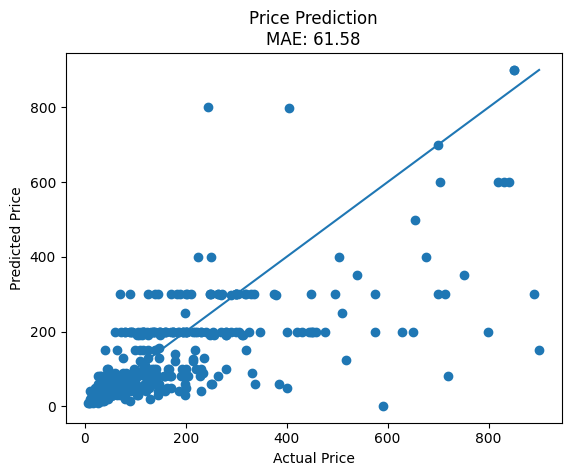

In [ ]:
## Plot Results

plt.scatter(actuals, predictions)

line = np.linspace(min(actuals), max(actuals))
plt.plot(line, line)

plt.title(f"Price Prediction\nMAE: {mae:.2f}")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.show()